# Empirical Mode Modulation

`empirical_mode_modulation` runs Empirical Mode Decomposition (EMD), randomly
rescales each IMF, then reconstructs. Optional **low-frequency enhancement**
sorts the scale factors so slower IMFs receive larger gains and high-frequency
IMFs are suppressed. The series is z-scored before EMD and restored to the
original mean / std afterwards, so the global energy is roughly preserved.

| Parameter | Default | Role |
| --- | --- | --- |
| `min_scale_factor` / `max_scale_factor` | 0.5 / 2.0 | Range of per-IMF multipliers |
| `low_frequency_enhancement` | True | Sort scales so low-freq IMFs are boosted |
| `spline_kind` | `"cubic"` | EMD envelope interpolant |
| `extrema_detection` | `"parabol"` | Extrema locator (`parabol` or `simple`) |
| `max_imfs` | None | Cap on the number of IMFs (`None` = full decomposition) |


In [1]:
%matplotlib inline
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(os.path.join("..", "..")))

from s2generator.utils import (
    load_univariate,
    generate_arma_samples,
    generate_nonstationary_sine,
    generate_chirp_signal,
)

L = 512
rng = np.random.RandomState(0)
np.random.seed(0)

synth = np.asarray(generate_arma_samples(L), dtype=float)
real = load_univariate("ETTh1")[:L].astype(float)


def overlay_pair(originals, variants, titles, ylabel="value"):
    # Plot original vs augmented traces for synth (left) and real (right).
    n = len(titles)
    fig, axes = plt.subplots(
        n, 2, figsize=(11.5, 2.55 * n), sharex=False, squeeze=False
    )
    col_titles = ["synthetic (ARMA)", "real (ETTh1 OT)"]
    for col, (orig, var_list) in enumerate(zip(originals, variants)):
        for row, (label, series) in enumerate(var_list):
            ax = axes[row, col]
            ax.plot(orig, color="0.55", lw=1.15, label="original")
            ax.plot(series, color="C0", lw=1.15, alpha=0.9, label=label)
            if row == 0:
                ax.set_title(col_titles[col], fontweight="bold")
            if col == 0:
                ax.set_ylabel(ylabel)
            ax.legend(fontsize=8, loc="upper right", frameon=False)
            ax.grid(True, alpha=0.3)
            axes[row, 0].set_ylabel(titles[row], fontsize=10)
    axes[-1, 0].set_xlabel("t")
    axes[-1, 1].set_xlabel("t")
    fig.tight_layout()
    return fig


def sweep_grid(series_list, names, makers, param_title):
    # makers: list of (label, fn) applied to each series.
    n_s, n_p = len(series_list), len(makers)
    fig, axes = plt.subplots(n_s, n_p, figsize=(3.6 * n_p, 2.5 * n_s), squeeze=False)
    for i, (series, name) in enumerate(zip(series_list, names)):
        for j, (label, fn) in enumerate(makers):
            ax = axes[i, j]
            ax.plot(series, color="0.55", lw=1.0, label="original")
            ax.plot(fn(series), color="C3", lw=1.05, alpha=0.9, label=label)
            if i == 0:
                ax.set_title(label, fontsize=10)
            if j == 0:
                ax.set_ylabel(name)
            ax.grid(True, alpha=0.3)
            if i == 0 and j == n_p - 1:
                ax.legend(fontsize=7, loc="upper right", frameon=False)
    fig.suptitle(param_title, y=1.02, fontweight="bold")
    fig.tight_layout()
    return fig


from s2generator.augmentation import empirical_mode_modulation

# EMD is smoother on an oscillatory synthetic than on ARMA noise
chirp = np.asarray(generate_chirp_signal(L), dtype=float)

## Default effect on synthetic (chirp) and real series


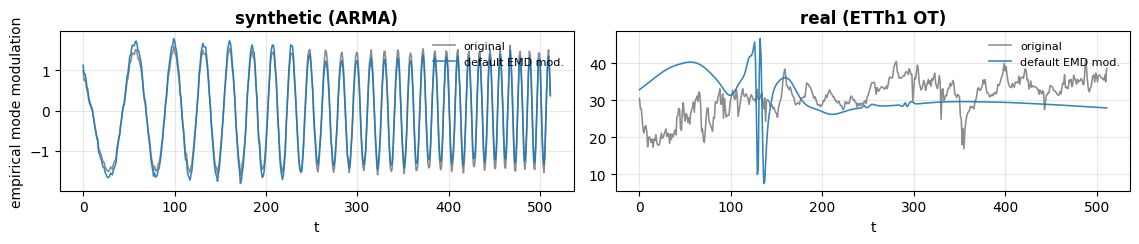

In [2]:
aug_s = empirical_mode_modulation(chirp, rng=np.random.RandomState(1))
aug_r = empirical_mode_modulation(real, rng=np.random.RandomState(1))
overlay_pair(
    [chirp, real],
    [[("default EMD mod.", aug_s)], [("default EMD mod.", aug_r)]],
    titles=["empirical mode modulation"],
)
plt.show()

## Parameter effect

A narrow scale band barely changes the signal. A wide band plus
`low_frequency_enhancement=False` can amplify residual noise. Capping `max_imfs`
leaves more of the residue unscaled.


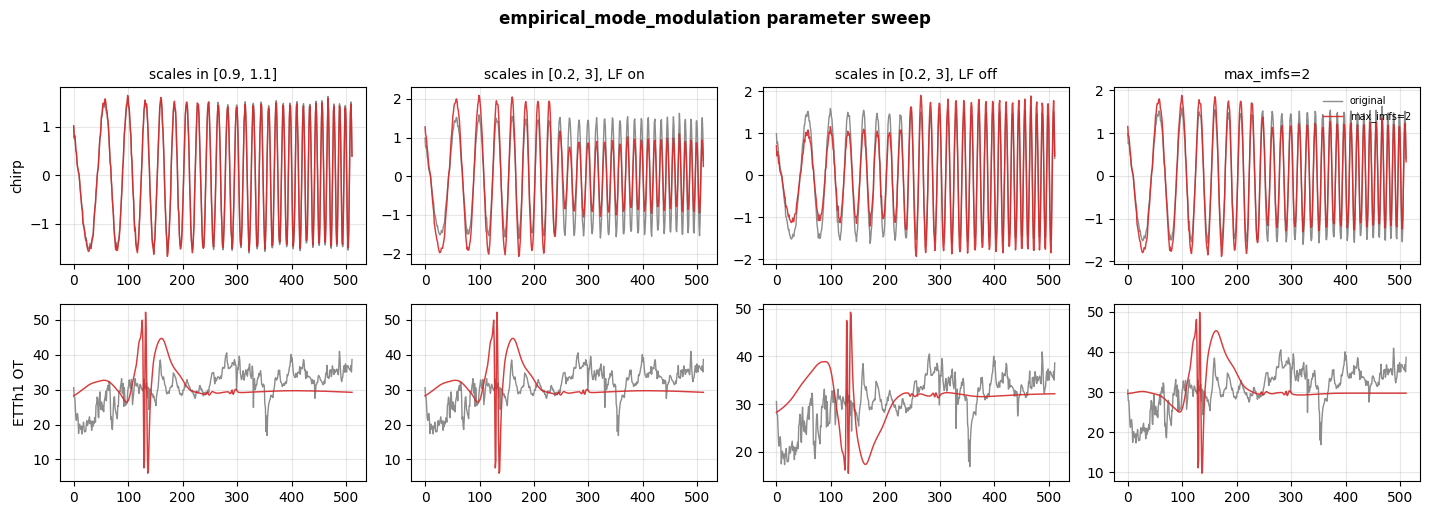

In [3]:
makers = [
    (
        "scales in [0.9, 1.1]",
        lambda x: empirical_mode_modulation(
            x, min_scale_factor=0.9, max_scale_factor=1.1, rng=np.random.RandomState(4)
        ),
    ),
    (
        "scales in [0.2, 3], LF on",
        lambda x: empirical_mode_modulation(
            x,
            min_scale_factor=0.2,
            max_scale_factor=3.0,
            low_frequency_enhancement=True,
            rng=np.random.RandomState(4),
        ),
    ),
    (
        "scales in [0.2, 3], LF off",
        lambda x: empirical_mode_modulation(
            x,
            min_scale_factor=0.2,
            max_scale_factor=3.0,
            low_frequency_enhancement=False,
            rng=np.random.RandomState(4),
        ),
    ),
    (
        "max_imfs=2",
        lambda x: empirical_mode_modulation(
            x, max_imfs=2, rng=np.random.RandomState(4)
        ),
    ),
]
sweep_grid(
    [chirp, real],
    ["chirp", "ETTh1 OT"],
    makers,
    "empirical_mode_modulation parameter sweep",
)
plt.show()